# Part 1: Baseline Sanity Check

We compare three molecule generation approaches:

1. **LSTM baseline**: directly generates SMILES strings token by token.
2. **VAE baseline (λ = 0)**: generates molecules from VAE latent vectors optimized for QED (Quantitative Estimate of Drug-likeness) only.
3. **Synthetic Accessibility-constrained VAE (λ = 0.5)**: generates molecules from VAE latent vectors optimized for both QED and a Synthetic Accessibility penalty.

For the constrained VAE, the generation reward is:

$$
R = \text{QED} - \lambda \cdot \text{SA}_{norm}
$$

where:

$$
\text{SA}_{norm} = (\text{SA} - 1) / 9
$$

A lower Synthetic Accessibility score means a molecule is easier to synthesize. We check whether adding the SA penalty moves generated molecules toward easier synthesis while preserving QED.

For reward-based reporting, all three methods are evaluated with the same fixed evaluation weight, **λ = 0.5**, so the reported reward is an SA-weighted reward.

In [1]:
import os
from pathlib import Path

import torch
import importlib

from tokenizer import SMILESTokenizer
import model as model_module
model_module = importlib.reload(model_module)
Encoder = model_module.Encoder
Decoder = model_module.Decoder
VAE = model_module.VAE

import generate as generate_module
generate_module = importlib.reload(generate_module)
NormalizedPropertyAdapter = generate_module.NormalizedPropertyAdapter
ConstrainedGenerator = generate_module.ConstrainedGenerator

from lstm_baseline import SMILESLanguageModel
from evaluate import compute_metrics, print_metrics
import warnings
warnings.filterwarnings("ignore")

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# Paths and runtime settings. Architectures are inferred from the checkpoints below.
VOCAB_PATH      = Path("vocab.json")
CSV_PATH        = Path("ZINC20-Druglike/zinc-druglike-cano.csv")
CKPT_DIR        = Path(os.environ.get("CKPT_DIR", "checkpoints"))
RESULTS_DIR     = Path(os.environ.get("RESULTS_DIR", "results"))
CHECK_PT        = CKPT_DIR / "vae_best.pt"
LSTM_CHECK_PT   = CKPT_DIR / "lstm_best.pt"
DEFAULT_PREDICTOR_PATH = CKPT_DIR / "predictors" / "normalized_property_heads.pt"
LEGACY_PREDICTOR_PATH = CKPT_DIR / "predictors" / "calibrated_property_heads.pt"
if DEFAULT_PREDICTOR_PATH.exists() or not LEGACY_PREDICTOR_PATH.exists():
    _predictor_default = DEFAULT_PREDICTOR_PATH
else:
    _predictor_default = LEGACY_PREDICTOR_PATH
PREDICTOR_PATH  = Path(os.environ.get("PREDICTOR_PATH", _predictor_default))

DROPOUT     = 0.1
TEMPERATURE = 0.8
GA_STEPS    = int(os.environ.get("GA_STEPS", 50))
GA_LR       = 0.01
BETA_ANCHOR = 0.01
N_MOLECULES = int(os.environ.get("N_MOLECULES", 200))
SEED        = 42

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def infer_vae_config(state_dict):
    vocab_size, embed_dim = state_dict["encoder.embedding.weight"].shape
    layer_dims = []
    i = 0
    while f"encoder.lstm_layers.{i}.weight_hh_l0" in state_dict:
        layer_dims.append(state_dict[f"encoder.lstm_layers.{i}.weight_hh_l0"].shape[1])
        i += 1
    latent_dim = state_dict["encoder.fc_mu.weight"].shape[0]
    hidden_dim = state_dict["decoder.lstm.weight_hh_l0"].shape[1]
    num_layers = 0
    while f"decoder.lstm.weight_hh_l{num_layers}" in state_dict:
        num_layers += 1
    return vocab_size, embed_dim, layer_dims, latent_dim, hidden_dim, num_layers


def infer_lstm_config(state_dict):
    embed_dim = state_dict["embedding.weight"].shape[1]
    hidden_dim = state_dict["lstm.weight_hh_l0"].shape[1]
    num_layers = 0
    while f"lstm.weight_hh_l{num_layers}" in state_dict:
        num_layers += 1
    return embed_dim, hidden_dim, num_layers


Device: cuda


In [2]:
# load tokenizer, VAE, and normalized property heads from checkpoint
tok = SMILESTokenizer()
tok.load(str(VOCAB_PATH))

ckpt = torch.load(CHECK_PT, map_location=device)
(vocab_size, EMBED_DIM, LAYER_DIMS, LATENT_DIM, HIDDEN_DIM, NUM_LAYERS) = infer_vae_config(ckpt["vae"])
if vocab_size != tok.vocab_size:
    raise ValueError(f"Tokenizer vocab size {tok.vocab_size} does not match VAE checkpoint vocab size {vocab_size}")

encoder = Encoder(tok.vocab_size, EMBED_DIM, LAYER_DIMS, LATENT_DIM, DROPOUT)
decoder = Decoder(tok.vocab_size, EMBED_DIM, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT)
vae = VAE(encoder, decoder).to(device)
vae.load_state_dict(ckpt["vae"])
vae.eval()
for p in vae.parameters():
    p.requires_grad_(False)
print(
    f"Loaded VAE checkpoint from epoch {ckpt['epoch']} | "
    f"embed={EMBED_DIM}, latent={LATENT_DIM}, hidden={HIDDEN_DIM}, layers={LAYER_DIMS}"
)

if not PREDICTOR_PATH.exists():
    raise FileNotFoundError(
        f"Missing normalized property head: {PREDICTOR_PATH}. "
        "Run train_property_heads.py before running this notebook."
    )
prop_adapter = NormalizedPropertyAdapter(PREDICTOR_PATH, device=device).eval()
for p in prop_adapter.parameters():
    p.requires_grad_(False)
if {"qed", "sa"} - set(prop_adapter.properties):
    raise ValueError(f"Property head must include qed and sa. Found: {prop_adapter.properties}")

# Keep the original notebook variable names; they now point to the normalized multi-head adapter.
pred_qed = prop_adapter
pred_sa = prop_adapter
print(f"Loaded normalized property heads: {', '.join(prop_adapter.properties)}")

# build reference set from first 10k training molecules for novelty scoring
reference_set = set()
with open(CSV_PATH) as f:
    next(f)
    for i, line in enumerate(f):
        smi = line.strip()
        if smi:
            reference_set.add(smi)
        if i >= 10_000:
            break
print(f"Reference set: {len(reference_set)} molecules")


Loaded VAE checkpoint from epoch 30 | embed=128, latent=128, hidden=480, layers=[256, 512]
Loaded normalized property heads: qed, sa, mw, scscore, syba
Reference set: 10001 molecules


In [3]:
# load LSTM baseline from checkpoint; infer dimensions from this checkpoint independently
lstm_ckpt = torch.load(LSTM_CHECK_PT, map_location=device)
LSTM_EMBED_DIM, LSTM_HIDDEN_DIM, LSTM_NUM_LAYERS = infer_lstm_config(lstm_ckpt["model"])
lstm = SMILESLanguageModel(
    tok.vocab_size,
    LSTM_EMBED_DIM,
    LSTM_HIDDEN_DIM,
    LSTM_NUM_LAYERS,
    DROPOUT,
).to(device)
lstm.load_state_dict(lstm_ckpt["model"])
lstm.eval()
print(
    f"Loaded LSTM checkpoint from epoch {lstm_ckpt['epoch']} | "
    f"embed={LSTM_EMBED_DIM}, hidden={LSTM_HIDDEN_DIM}, layers={LSTM_NUM_LAYERS}"
)


Loaded LSTM checkpoint from epoch 15 | embed=128, hidden=512, layers=2


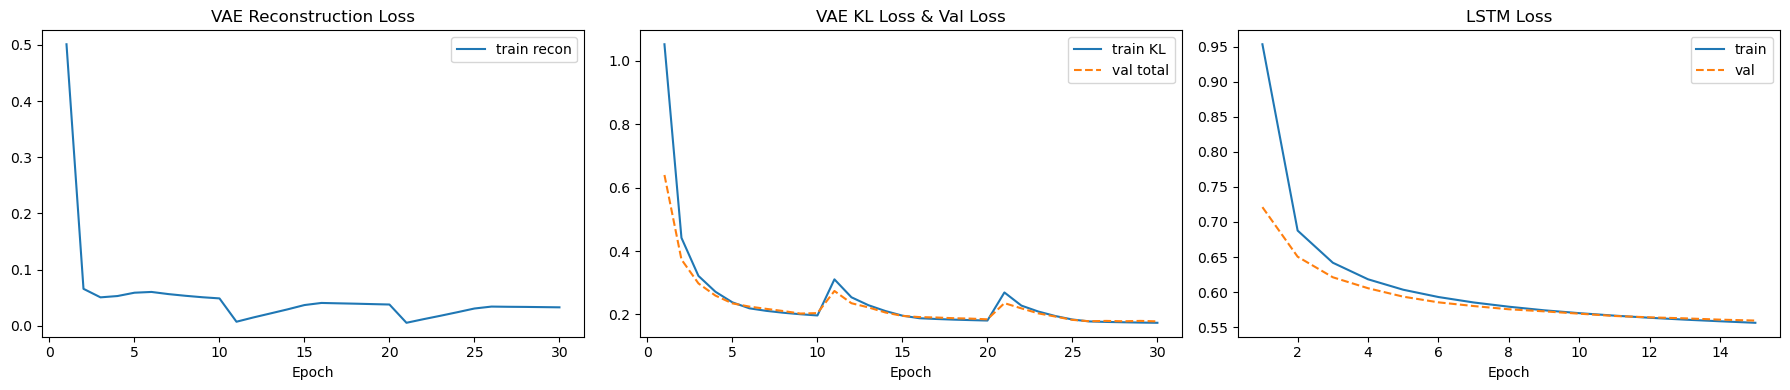

Saved results/loss_curve.png


In [4]:
import json
import matplotlib.pyplot as plt

vae_history = None
vae_history_path = RESULTS_DIR / "vae_loss_history.json"
if vae_history_path.exists():
    with open(vae_history_path) as f:
        vae_history = json.load(f)
else:
    print(f"VAE loss history not found: {vae_history_path}")

lstm_history = None
lstm_history_path = RESULTS_DIR / "lstm_loss_history.json"
if lstm_history_path.exists():
    with open(lstm_history_path) as f:
        lstm_history = json.load(f)
else:
    print(f"LSTM loss history not found: {lstm_history_path}")

n_plots = int(vae_history is not None) * 2 + int(lstm_history is not None)
if n_plots == 0:
    print("No loss histories found; skipping loss-curve plot.")
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    ax_idx = 0

    if vae_history is not None:
        vae_epochs = range(1, len(vae_history["val_loss"]) + 1)
        axes[ax_idx].plot(vae_epochs, vae_history["train_recon"], label="train recon")
        axes[ax_idx].set_title("VAE Reconstruction Loss")
        axes[ax_idx].set_xlabel("Epoch")
        axes[ax_idx].legend()
        ax_idx += 1

        axes[ax_idx].plot(vae_epochs, vae_history["train_kl"], label="train KL")
        axes[ax_idx].plot(vae_epochs, vae_history["val_loss"], label="val total", linestyle="--")
        axes[ax_idx].set_title("VAE KL Loss & Val Loss")
        axes[ax_idx].set_xlabel("Epoch")
        axes[ax_idx].legend()
        ax_idx += 1

    if lstm_history is not None:
        lstm_epochs = range(1, len(lstm_history["val_loss"]) + 1)
        axes[ax_idx].plot(lstm_epochs, lstm_history["train_loss"], label="train")
        axes[ax_idx].plot(lstm_epochs, lstm_history["val_loss"], label="val", linestyle="--")
        axes[ax_idx].set_title("LSTM Loss")
        axes[ax_idx].set_xlabel("Epoch")
        axes[ax_idx].legend()

    plt.tight_layout()
    loss_curve_path = RESULTS_DIR / "loss_curve.png"
    plt.savefig(loss_curve_path, dpi=150)
    plt.show()
    print(f"Saved {loss_curve_path}")


In [5]:
# generate with VAE baseline
torch.manual_seed(SEED)
part1_z_start = torch.randn(N_MOLECULES, LATENT_DIM, device=device)
torch.manual_seed(SEED + 100)
gen_baseline = ConstrainedGenerator(vae, pred_qed, pred_sa, tok, lambda_=0.0, beta=BETA_ANCHOR, device=device)
smiles_baseline = gen_baseline.generate(N_MOLECULES, z_init=part1_z_start.clone(), n_steps=GA_STEPS, ga_lr=GA_LR, temperature=TEMPERATURE)
print("VAE baseline (λ=0) samples:")
for s in smiles_baseline[:5]:
    print(" ", s)


VAE baseline (λ=0) samples:
  CNC(=O)[C@@H]1CC[C@H]1NC(=O)Cn1cnnn1
  O=C1CCN(C[C@@H]2NOCCO2)CCN1C
  CNC(=O)[C@@H]1COCCN1[C@@H]1CCNC1
  O=C([C@@H]1CCNC1)N1C[C@H](O)C2(CCNC2)C1
  CN1C[C@@H]2OCCN(CCn3ncnn3)[C@H]2C1


In [6]:
# generate with SA constrained-VAE with lambda=0.5
torch.manual_seed(SEED + 100)
gen_constrained = ConstrainedGenerator(vae, pred_qed, pred_sa, tok, lambda_=0.5, beta=BETA_ANCHOR, device=device)
smiles_constrained = gen_constrained.generate(N_MOLECULES, z_init=part1_z_start.clone(), n_steps=GA_STEPS, ga_lr=GA_LR, temperature=TEMPERATURE)

print("SA Constrained VAE (λ=0.5) samples:")
for s in smiles_constrained[:5]:
    print(" ", s)


SA Constrained VAE (λ=0.5) samples:
  CNC(=O)C1CN(C(=O)[C@@H]2COCCO2)C1
  O=C1CNC[C@@H](CNS(=O)(=O)NC2CCOC2)O1
  CNC(=O)CN1CC[C@@H](NC2=OCC2)C1
  O=C(C1=CCNC1)N1C[C@H](O)C2(CCNC2)C1
  CN1CCn2nc(CNCCO)n2c1=O


In [7]:
# generate with LSTM baseline
torch.manual_seed(SEED + 200)
smiles_lstm = lstm.sample(N_MOLECULES, tok, temperature=TEMPERATURE, device=device)

print("LSTM baseline samples:")
for s in smiles_lstm[:5]:
    print(" ", s)


LSTM baseline samples:
  CCOC(=O)NCC(=O)NCC(N)=O
  CN(Cc1ncon1)C(=O)[C@@H]1C[C@H](O)CN1
  Cn1cc(NC(=O)CNC[C@@H](O)CO)nn1
  NC(=O)COCCN1[C@H]2CCNC[C@H]1COC2
  CC(C)C(=O)N1C[C@H](CO)[C@H](O)[C@@H](O)C1


In [8]:
# Part 1 metrics: fixed evaluation reward QED - 0.5 * SA_norm
import pandas as pd

EVAL_LAMBDA = 0.5
part1_metrics = {
    "LSTM baseline": compute_metrics(smiles_lstm, reference_set=reference_set, lambda_=EVAL_LAMBDA),
    "VAE": compute_metrics(smiles_baseline, reference_set=reference_set, lambda_=EVAL_LAMBDA),
    "SA-constrained VAE (λ=0.5)": compute_metrics(smiles_constrained, reference_set=reference_set, lambda_=EVAL_LAMBDA),
}

part1_df = pd.DataFrame(part1_metrics).T.rename(
    columns={"mean_reward": "SA_weighted_reward"}
)

part1_df = part1_df[
    ["validity", "uniqueness", "novelty", "mean_qed", "mean_sa", "SA_weighted_reward"]
]
display(part1_df)
print(f"Reward columns use fixed evaluation λ={EVAL_LAMBDA}: QED - λ * SA_norm")


,validity,uniqueness,novelty,mean_qed,mean_sa,SA_weighted_reward
LSTM baseline,0.995,1.0,0.989950,0.530730,3.452311,0.394491
VAE,0.930,1.0,1.000000,0.568697,3.753500,0.415725
SA-constrained VAE (λ=0.5),0.935,1.0,0.989305,0.563203,3.636200,0.416747


Reward columns use fixed evaluation λ=0.5: QED - λ * SA_norm


---
## Part 2 — Ablation Study:

We perform an ablation study across four economic constraint terms:

- **SA**: Synthetic Accessibility score
- **SCScore**: Synthetic Complexity Score
- **SYBA**: Synthetic Bayesian Accessibility score
- **MW**: Molecular Weight

For each constraint, we generate molecules with:

$$
R = \text{QED} - \lambda \cdot \text{Constraint}_{norm}
$$

where λ ∈ {0.0, 0.2, 0.5, 1.0}.

We evaluate the following metrics for each constraint:

1. **Mmolecular properties**: validity, uniqueness, novelty, QED, SA, SCScore, SYBA, and MW.
2. **Target-constraint improvement**: whether increasing λ improves the intended target metric while preserving QED.
3. **Cross-constraint behavior**: whether optimizing one synthesizability proxy also improves the others.
4. **Tradeoffs**: whether a method achieves better synthesis-related properties at comparable QED.

In [9]:
# ── load normalized property heads and external scorers ───────────────────
import sys, os as _os
import contextlib
import io
_scscore_path = _os.path.join(_os.getcwd(), "scscore_repo")
if _scscore_path not in sys.path:
    sys.path.insert(0, _scscore_path)

from scscore.standalone_model_numpy import SCScorer
from syba.syba import SybaClassifier

available_props = set(prop_adapter.properties)
original_constraints = {"sa", "scscore", "syba", "mw"}
missing_constraints = sorted(original_constraints - available_props)
if missing_constraints:
    print(
        "Skipping optimizer(s) without normalized heads: " + ", ".join(missing_constraints) +
        ". To run the full original ablation, retrain heads with PROPERTIES=qed,sa,mw,scscore,syba."
    )

# scorers for post-hoc evaluation
sc_scorer = SCScorer()
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    sc_scorer.restore(weight_path=_os.path.join(_scscore_path, "models",
                      "full_reaxys_model_1024bool", "model.ckpt-10654.as_numpy.json.gz"))
syba_clf = SybaClassifier()
syba_clf.fitDefaultScore()
print(f"Loaded normalized heads: {', '.join(prop_adapter.properties)}")
print("Post-hoc SCScore and SYBA scorers loaded")


Loaded normalized heads: qed, sa, mw, scscore, syba
Post-hoc SCScore and SYBA scorers loaded


In [10]:
from generate import ConstrainedGenerator

# Cost functions return normalized costs where larger means more expensive/harder.
def standardized_cost(prop, higher_is_better=False):
    idx = prop_adapter.property_to_idx[prop]
    def _cost(z):
        raw = prop_adapter.predict_property(z, prop)
        y_mean = prop_adapter.y_mean[:, idx:idx + 1].to(z.device)
        y_std = prop_adapter.y_std[:, idx:idx + 1].clamp_min(1e-6).to(z.device)
        scaled = torch.sigmoid((raw - y_mean) / y_std)
        return 1.0 - scaled if higher_is_better else scaled
    return _cost

cost_fns = {}
if "sa" in available_props:
    cost_fns["SA"] = lambda z: (pred_sa.predict_sa(z) - 1.0) / 9.0
if "scscore" in available_props:
    cost_fns["SCScore"] = standardized_cost("scscore", higher_is_better=False)
if "syba" in available_props:
    cost_fns["SYBA"] = standardized_cost("syba", higher_is_better=True)
if "mw" in available_props:
    cost_fns["MW"] = standardized_cost("mw", higher_is_better=False)
if not cost_fns:
    raise RuntimeError("No normalized constraint heads are available for ablation generation.")

LAMBDAS = [0.0, 0.2, 0.5, 1.0]

# Use the same latent starts and decoding seed across every ablation run.
# This keeps differences focused on the objective instead of sampling noise.
latent_dim = vae.encoder.fc_mu.out_features
torch.manual_seed(SEED)
z_ablation_start = torch.randn(N_MOLECULES, latent_dim, device=device)

ablation_smiles = {}   # key: (cost_name, lambda) -> smiles list

for cost_name, cost_fn in cost_fns.items():
    for lam in LAMBDAS:
        key = (cost_name, lam)
        gen = ConstrainedGenerator(
            vae, pred_qed, pred_sa, tok,
            lambda_=lam,
            beta=BETA_ANCHOR,
            device=device,
            cost_fn=cost_fn,
        )
        torch.manual_seed(SEED + 1000)
        smiles = gen.generate(
            N_MOLECULES,
            z_init=z_ablation_start.clone(),
            n_steps=GA_STEPS,
            ga_lr=GA_LR,
            temperature=TEMPERATURE,
        )
        ablation_smiles[key] = smiles
        print(f"  {cost_name} λ={lam} done ({len(smiles)} molecules)")

ablation_smiles[("LSTM", None)] = smiles_lstm
print("Ablation generation complete")


  SA λ=0.0 done (200 molecules)
  SA λ=0.2 done (200 molecules)
  SA λ=0.5 done (200 molecules)
  SA λ=1.0 done (200 molecules)
  SCScore λ=0.0 done (200 molecules)
  SCScore λ=0.2 done (200 molecules)
  SCScore λ=0.5 done (200 molecules)
  SCScore λ=1.0 done (200 molecules)
  SYBA λ=0.0 done (200 molecules)
  SYBA λ=0.2 done (200 molecules)
  SYBA λ=0.5 done (200 molecules)
  SYBA λ=1.0 done (200 molecules)
  MW λ=0.0 done (200 molecules)
  MW λ=0.2 done (200 molecules)
  MW λ=0.5 done (200 molecules)
  MW λ=1.0 done (200 molecules)
Ablation generation complete


In [11]:
# Pre-score all generated SMILES with SYBA now, then free the ~900 MB model.
# syba_clf is only needed for this lookup — after this cell it is gone.
import gc
from rdkit import Chem

_syba_cache = {}
for _smiles_list in ablation_smiles.values():
    for _smi in _smiles_list:
        if _smi and _smi not in _syba_cache:
            _mol = Chem.MolFromSmiles(_smi)
            if _mol is not None:
                _syba_cache[_smi] = float(syba_clf.predict(mol=_mol))

del syba_clf
gc.collect()
print(f"SYBA cache built: {len(_syba_cache)} unique molecules — syba_clf freed")


SYBA cache built: 2179 unique molecules — syba_clf freed


In [12]:
import gc
from rdkit import Chem
from rdkit.Chem import QED as rdkit_QED, Descriptors
import rdkit as _rdkit, sys as _sys2
_contrib2 = os.path.join(_rdkit.__path__[0], "Contrib")
if _contrib2 not in _sys2.path:
    _sys2.path.insert(0, _contrib2)
from SA_Score import sascorer as _sascorer
from evaluate import novelty

def compute_ablation_metrics(smiles_list):
    parsed = [(s, Chem.MolFromSmiles(s)) for s in smiles_list if s]
    valid_pairs = [(s, m) for s, m in parsed if m is not None]

    n_total = len(smiles_list)
    val_rate = len(valid_pairs) / n_total if n_total else 0.0

    seen, unique_pairs = {}, []
    for s, m in valid_pairs:
        can = Chem.MolToSmiles(m)
        if can not in seen:
            seen[can] = True
            unique_pairs.append((can, m))

    n_valid = len(valid_pairs)
    uniq_rate = len(unique_pairs) / n_valid if n_valid else 0.0
    nov_rate = novelty([s for s, _ in unique_pairs], reference_set)

    qed_s, sa_s, sc_s, syba_s, mw_s = [], [], [], [], []
    for smi, mol in unique_pairs:
        qed_s.append(float(rdkit_QED.qed(mol)))
        sa_s.append(float(_sascorer.calculateScore(mol)))
        _, sc = sc_scorer.get_score_from_smi(smi)
        sc_s.append(float(sc))
        syba_s.append(_syba_cache.get(smi, 0.0))
        mw_s.append(float(Descriptors.MolWt(mol)))

    return {
        "validity":     val_rate,
        "uniqueness":   uniq_rate,
        "novelty":      nov_rate,
        "mean_qed":     sum(qed_s)  / len(qed_s)   if qed_s   else 0.0,
        "mean_sa":      sum(sa_s)   / len(sa_s)    if sa_s    else 10.0,
        "mean_scscore": sum(sc_s)   / len(sc_s)    if sc_s    else 5.0,
        "mean_syba":    sum(syba_s) / len(syba_s)  if syba_s  else 0.0,
        "mean_mw":      sum(mw_s)   / len(mw_s)    if mw_s    else 0.0,
    }

ablation_metrics = {}
for k, v in ablation_smiles.items():
    ablation_metrics[k] = compute_ablation_metrics(v)
    gc.collect()
print("Metrics computed")


Metrics computed


In [13]:
import pandas as pd

metrics_keys = [
    "validity", "uniqueness", "novelty", "mean_qed",
    "mean_sa", "mean_scscore", "mean_syba", "mean_mw",
]

metric_labels = {
    "validity": "validity",
    "uniqueness": "uniqueness",
    "novelty": "novelty",
    "mean_qed": "QED ↑",
    "mean_sa": "SA ↓",
    "mean_scscore": "SCScore ↓",
    "mean_syba": "SYBA ↑",
    "mean_mw": "MW ↓",
}

constraint_metric = {
    "SA": "mean_sa",
    "SCScore": "mean_scscore",
    "SYBA": "mean_syba",
    "MW": "mean_mw",
}

# Direction is defined according to the cost used during generation.
# For MW, the current predictor is a normalized MW cost, so lower MW is treated as lower cost.
constraint_direction = {
    "SA": "lower",
    "SCScore": "lower",
    "SYBA": "higher",
    "MW": "lower",
}

rows = []
rows.append({
    "generator": "LSTM baseline",
    "optimized_cost": "none",
    "λ": "n/a",
    **{k: ablation_metrics[("LSTM", None)][k] for k in metrics_keys},
})

for cost_name in cost_fns:
    for lam in LAMBDAS:
        m = ablation_metrics[(cost_name, lam)]
        rows.append({
            "generator": f"VAE + {cost_name}",
            "optimized_cost": cost_name,
            "λ": lam,
            **{k: m[k] for k in metrics_keys},
        })

ablation_df = pd.DataFrame(rows)
display(ablation_df)



,generator,optimized_cost,λ,validity,uniqueness,novelty,mean_qed,mean_sa,mean_scscore,mean_syba,mean_mw
0,LSTM baseline,none,n/a,0.995,1.0,0.989950,0.530730,3.452311,3.360560,11.200971,231.106899
1,VAE + SA,SA,0.0,0.940,1.0,0.994681,0.564720,3.743841,3.416272,-0.754592,228.981702
2,VAE + SA,SA,0.2,0.915,1.0,1.000000,0.565586,3.710236,3.444290,1.140418,229.426000
3,VAE + SA,SA,0.5,0.935,1.0,1.000000,0.556290,3.653617,3.389052,3.613726,230.159551
4,VAE + SA,SA,1.0,0.950,1.0,1.000000,0.555184,3.566152,3.423485,7.824234,229.072884
5,VAE + SCScore,SCScore,0.0,0.940,1.0,0.994681,0.564720,3.743841,3.416272,-0.754592,228.981702
6,VAE + SCScore,SCScore,0.2,0.950,1.0,0.984211,0.556411,3.764794,3.386213,1.322462,230.374621
7,VAE + SCScore,SCScore,0.5,0.935,1.0,0.994652,0.547436,3.657264,3.338577,2.064892,229.942941
8,VAE + SCScore,SCScore,1.0,0.960,1.0,1.000000,0.540429,3.622007,3.298406,1.322877,227.660073
9,VAE + SYBA,SYBA,0.0,0.940,1.0,0.994681,0.564720,3.743841,3.416272,-0.754592,228.981702


### 2A — Target-Constraint Improvement

For each optimized cost term, compare λ > 0 against that same cost term's λ = 0 baseline. This checks whether the constraint actually moves its intended target metric, and how much QED is changed in exchange.

In [14]:
target_rows = []
for cost_name in cost_fns:
    target_metric = constraint_metric[cost_name]
    base = ablation_df[(ablation_df["optimized_cost"] == cost_name) & (ablation_df["λ"] == 0.0)].iloc[0]
    for lam in [v for v in LAMBDAS if v != 0.0]:
        row = ablation_df[(ablation_df["optimized_cost"] == cost_name) & (ablation_df["λ"] == lam)].iloc[0]
        raw_delta = row[target_metric] - base[target_metric]
        target_improvement = -raw_delta if constraint_direction[cost_name] == "lower" else raw_delta
        target_rows.append({
            "optimized_cost":    cost_name,
            "lambda":            lam,
            "target_metric":     metric_labels[target_metric],
            "delta_improvement": target_improvement,
            "delta_raw":         raw_delta,
            "delta_QED":         row["mean_qed"] - base["mean_qed"],
            "target_baseline":   base[target_metric],
            "target_value":      row[target_metric],
            "QED_baseline":      base["mean_qed"],
            "QED_value":         row["mean_qed"],
        })

target_delta_df = pd.DataFrame(target_rows)
display(target_delta_df)


,optimized_cost,lambda,target_metric,delta_improvement,delta_raw,delta_QED,target_baseline,target_value,QED_baseline,QED_value
0,SA,0.2,SA ↓,0.033605,-0.033605,0.000866,3.743841,3.710236,0.56472,0.565586
1,SA,0.5,SA ↓,0.090224,-0.090224,-0.008430,3.743841,3.653617,0.56472,0.556290
2,SA,1.0,SA ↓,0.177689,-0.177689,-0.009537,3.743841,3.566152,0.56472,0.555184
3,SCScore,0.2,SCScore ↓,0.030059,-0.030059,-0.008309,3.416272,3.386213,0.56472,0.556411
4,SCScore,0.5,SCScore ↓,0.077696,-0.077696,-0.017284,3.416272,3.338577,0.56472,0.547436
5,SCScore,1.0,SCScore ↓,0.117866,-0.117866,-0.024291,3.416272,3.298406,0.56472,0.540429
6,SYBA,0.2,SYBA ↑,3.223922,3.223922,-0.001418,-0.754592,2.469330,0.56472,0.563302
7,SYBA,0.5,SYBA ↑,7.654349,7.654349,-0.009945,-0.754592,6.899757,0.56472,0.554775
8,SYBA,1.0,SYBA ↑,10.113441,10.113441,-0.023234,-0.754592,9.358849,0.56472,0.541486
9,MW,0.2,MW ↓,5.022337,-5.022337,-0.006617,228.981702,223.959366,0.56472,0.558103


### 2B — Cross-Constraint Behavior

This table checks whether optimizing one cost constraint also improves/harms the other synthesizability proxies. A useful constraint should ideally improve its target without degrading QED or simply improving one metric.

In [15]:
CROSS_LAMBDA = 0.5
cross_rows = []
for cost_name in cost_fns:
    row = ablation_df[(ablation_df["optimized_cost"] == cost_name) & (ablation_df["λ"] == CROSS_LAMBDA)].iloc[0]
    cross_rows.append({
        "generated_with": f"{cost_name}, λ={CROSS_LAMBDA}",
        "QED ↑": row["mean_qed"],
        "SA ↓": row["mean_sa"],
        "SCScore ↓": row["mean_scscore"],
        "SYBA ↑": row["mean_syba"],
        "MW ↓": row["mean_mw"],
    })

reference_cost = "SA" if "SA" in cost_fns else next(iter(cost_fns))
base = ablation_df[(ablation_df["optimized_cost"] == reference_cost) & (ablation_df["λ"] == 0.0)].iloc[0]
cross_rows.insert(0, {
    "generated_with": "VAE λ=0 reference",
    "QED ↑": base["mean_qed"],
    "SA ↓": base["mean_sa"],
    "SCScore ↓": base["mean_scscore"],
    "SYBA ↑": base["mean_syba"],
    "MW ↓": base["mean_mw"],
})

lstm_row = ablation_df[ablation_df["optimized_cost"] == "none"].iloc[0]
cross_rows.insert(0, {
    "generated_with": "LSTM baseline",
    "QED ↑": lstm_row["mean_qed"],
    "SA ↓": lstm_row["mean_sa"],
    "SCScore ↓": lstm_row["mean_scscore"],
    "SYBA ↑": lstm_row["mean_syba"],
    "MW ↓": lstm_row["mean_mw"],
})

cross_constraint_df = pd.DataFrame(cross_rows)
display(cross_constraint_df)
print("Arrows indicate the preferred direction for each measured metric.")


,generated_with,QED ↑,SA ↓,SCScore ↓,SYBA ↑,MW ↓
0,LSTM baseline,0.530730,3.452311,3.360560,11.200971,231.106899
1,VAE λ=0 reference,0.564720,3.743841,3.416272,-0.754592,228.981702
2,"SA, λ=0.5",0.556290,3.653617,3.389052,3.613726,230.159551
3,"SCScore, λ=0.5",0.547436,3.657264,3.338577,2.064892,229.942941
4,"SYBA, λ=0.5",0.554775,3.550906,3.422700,6.899757,230.704521
5,"MW, λ=0.5",0.541902,3.687521,3.341590,0.116791,221.734649


Arrows indicate the preferred direction for each measured metric.


### 2C — Tradeoff Plots

Each plot shows: does increasing the synthesis penalty (λ) improve the target metric without sacrificing (QED)?

- X-axis: mean QED of 200 generated molecules — higher is more drug-like (range is narrow because all models are already good at this)
- Y-axis: synthesizability constraint — the direction that is better is labelled with an arrow (↑ or ↓)
- Each line: one constraint type (SA, SCScore, SYBA, or MW) — the four dots along it are λ = 0.0, 0.2, 0.5, 1.0
- Good outcome: the line moves toward the right + the good direction as λ increases, meaning the constraint helps without hurting QED

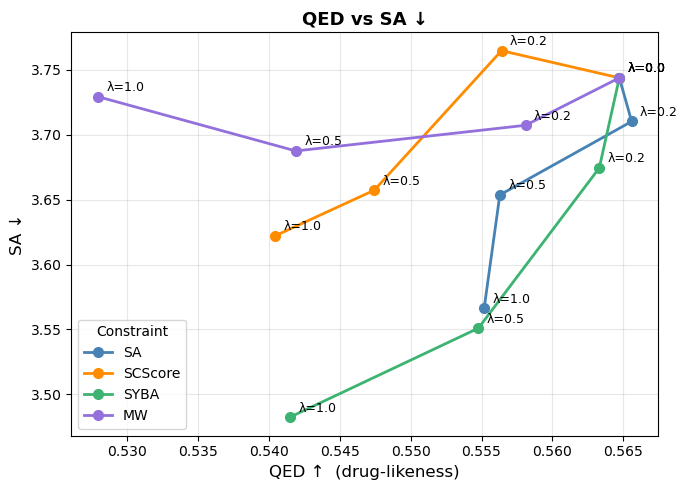

Saved results/ablation_pareto_mean_sa.png


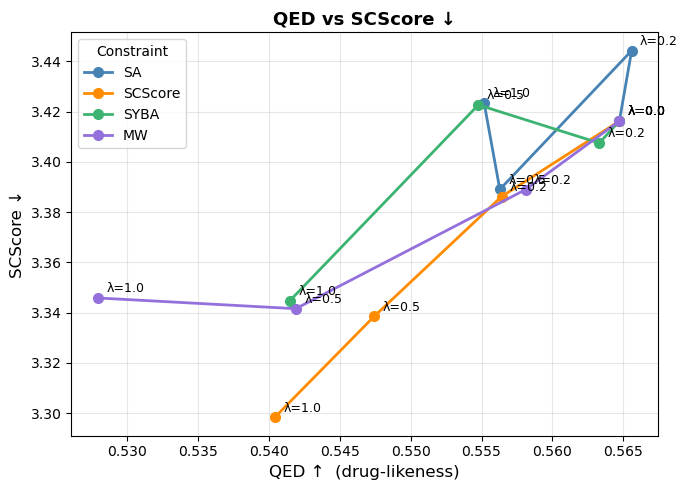

Saved results/ablation_pareto_mean_scscore.png


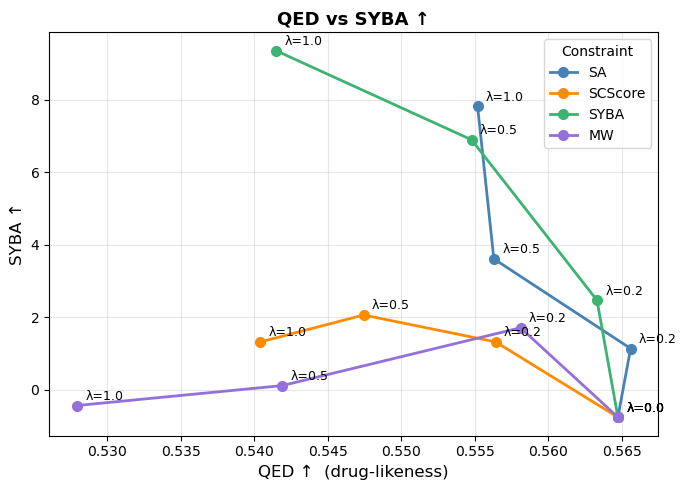

Saved results/ablation_pareto_mean_syba.png


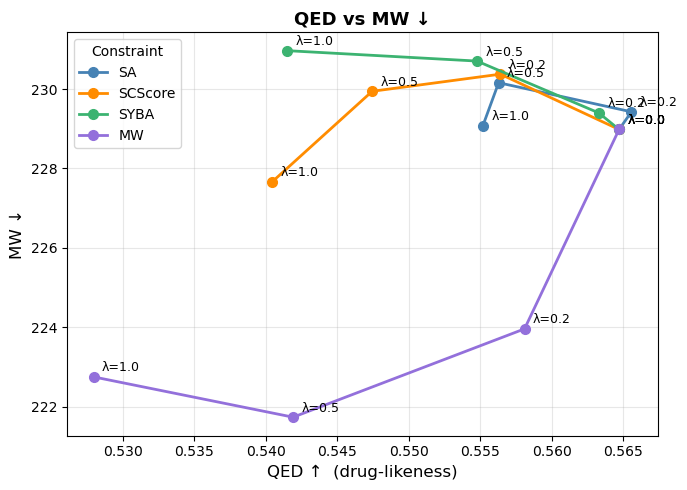

Saved results/ablation_pareto_mean_mw.png


In [16]:
import matplotlib.pyplot as plt

colors = {"SA": "steelblue", "SCScore": "darkorange", "SYBA": "mediumseagreen", "MW": "mediumpurple"}
pareto_metrics = [
    ("mean_sa",      metric_labels["mean_sa"]),
    ("mean_scscore", metric_labels["mean_scscore"]),
    ("mean_syba",    metric_labels["mean_syba"]),
    ("mean_mw",      metric_labels["mean_mw"]),
]

for metric, ylabel in pareto_metrics:
    fig, ax = plt.subplots(figsize=(7, 5))
    for cost_name in cost_fns:
        sub = ablation_df[ablation_df["optimized_cost"] == cost_name].sort_values("λ")
        ax.plot(sub["mean_qed"], sub[metric], marker="o", color=colors.get(cost_name),
                label=cost_name, linewidth=2, markersize=7)
        for _, r in sub.iterrows():
            ax.annotate(f"λ={r['λ']}", (r["mean_qed"], r[metric]),
                        fontsize=9, xytext=(6, 4), textcoords="offset points")
    ax.set_xlabel("QED ↑  (drug-likeness)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"QED vs {ylabel}", fontsize=13, fontweight="bold")
    ax.legend(title="Constraint", fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = RESULTS_DIR / f"ablation_pareto_{metric}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved {fname}")



## Part 3 — Property Predictor Calibration Check

Encodes held-out molecules and compares predicted vs RDKit-computed QED and SA.  
R² > 0.7 on both validates that gradient ascent meaningfully steers latent vectors.


In [17]:
from sklearn.metrics import r2_score
import numpy as np

HELD_OUT_N   = int(os.environ.get("HELD_OUT_N", 500))
TRAIN_OFFSET = 500_000
held_out = []
with open(CSV_PATH) as f:
    next(f)
    for i, line in enumerate(f):
        if i >= TRAIN_OFFSET:
            smi = line.strip()
            if smi:
                held_out.append(smi)
        if len(held_out) >= HELD_OUT_N:
            break
print(f"Held-out set: {len(held_out)} molecules")


Held-out set: 500 molecules


In [18]:
from rdkit import Chem
from rdkit.Chem import QED as rdkit_QED
import rdkit, sys as _sys
import os as _os
_contrib = _os.path.join(rdkit.__path__[0], "Contrib")
if _contrib not in _sys.path:
    _sys.path.insert(0, _contrib)
from SA_Score import sascorer

valid_held = [s for s in held_out if Chem.MolFromSmiles(s) is not None]
true_qed = [float(rdkit_QED.qed(Chem.MolFromSmiles(s))) for s in valid_held]
true_sa  = [float(sascorer.calculateScore(Chem.MolFromSmiles(s))) for s in valid_held]

mu_held = vae.encode(valid_held, tok, device, batch_size=128)
pred_qed_vals = pred_qed.predict_qed(mu_held).squeeze().cpu().detach().numpy()
pred_sa_vals  = pred_sa.predict_sa(mu_held).squeeze().cpu().detach().numpy()

r2_qed = r2_score(true_qed, pred_qed_vals)
r2_sa  = r2_score(true_sa,  pred_sa_vals)
print(f"R²  QED: {r2_qed}   (> 0.7 needed for reliable gradient ascent)")
print(f"R²  SA:  {r2_sa}   (> 0.7 needed for reliable gradient ascent)")


R²  QED: 0.7836586236953735   (> 0.7 needed for reliable gradient ascent)
R²  SA:  0.8486197590827942   (> 0.7 needed for reliable gradient ascent)


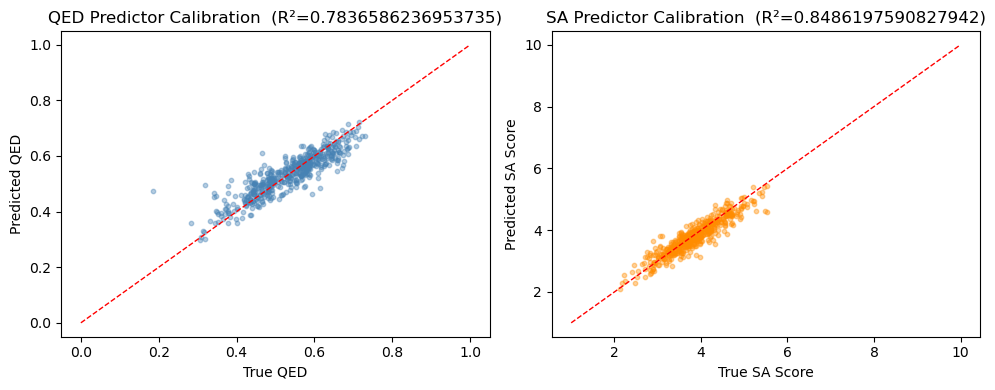

Saved results/predictor_calibration.png


In [19]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(true_qed, pred_qed_vals, alpha=0.4, s=10, color="steelblue")
axes[0].plot([0, 1], [0, 1], "r--", lw=1)
axes[0].set_xlabel("True QED"); axes[0].set_ylabel("Predicted QED")
axes[0].set_title(f"QED Predictor Calibration  (R²={r2_qed})")

axes[1].scatter(true_sa, pred_sa_vals, alpha=0.4, s=10, color="darkorange")
axes[1].plot([1, 10], [1, 10], "r--", lw=1)
axes[1].set_xlabel("True SA Score"); axes[1].set_ylabel("Predicted SA Score")
axes[1].set_title(f"SA Predictor Calibration  (R²={r2_sa})")

plt.tight_layout()
predictor_plot_path = RESULTS_DIR / "predictor_calibration.png"
plt.savefig(predictor_plot_path, dpi=150)
plt.show()
print(f"Saved {predictor_plot_path}")


## Part 4 — Additional Experiments


### Using Hard SA Feasibility Threshold To Filter Generation
Fraction of generated molecules with SA ≤ 4, across all ablation models.


In [22]:
from evaluate import feasibility_rate

print(f"{'model':<22}  feasibility (SA≤4)")
print("-" * 42)
m = ablation_metrics[("LSTM", None)]
rate, _ = feasibility_rate(ablation_smiles[("LSTM", None)], sa_threshold=4)
print(f"{'LSTM baseline':<22}  {rate:.3f}")
for cost_name in cost_fns:
    for lam in LAMBDAS:
        rate, _ = feasibility_rate(ablation_smiles[(cost_name, lam)], sa_threshold=4)
        print(f"  {cost_name:<8} λ={lam:<4}       {rate:.3f}")


model                   feasibility (SA≤4)
------------------------------------------
LSTM baseline           0.845
  SA       λ=0.0        0.650
  SA       λ=0.2        0.640
  SA       λ=0.5        0.680
  SA       λ=1.0        0.715
  SCScore  λ=0.0        0.650
  SCScore  λ=0.2        0.595
  SCScore  λ=0.5        0.680
  SCScore  λ=1.0        0.685
  SYBA     λ=0.0        0.650
  SYBA     λ=0.2        0.670
  SYBA     λ=0.5        0.720
  SYBA     λ=1.0        0.750
  MW       λ=0.0        0.650
  MW       λ=0.2        0.685
  MW       λ=0.5        0.665
  MW       λ=1.0        0.630


### Combined Multi-Constraint

Generate with combined 4 constraints (equal weight).

In [21]:
LAMBDA_COMBINED = 0.5
if not cost_fns:
    raise RuntimeError("Run the ablation setup cell before the combined-constraint experiment.")

per_term = LAMBDA_COMBINED / len(cost_fns)
cost_terms_combined = [(fn, per_term) for fn in cost_fns.values()]

# Reuse the same latent starts so the combined run is comparable to the ablation panel.
gen_combined = ConstrainedGenerator(vae, pred_qed, pred_sa, tok,
                                     beta=BETA_ANCHOR, device=device,
                                     cost_terms=cost_terms_combined)
smiles_combined = gen_combined.generate(N_MOLECULES, z_init=z_ablation_start.clone(), n_steps=GA_STEPS,
                                         ga_lr=GA_LR, temperature=TEMPERATURE)

m_combined = compute_ablation_metrics(smiles_combined)
baseline_key = ("SA", 0.5) if ("SA", 0.5) in ablation_metrics else next(
    key for key in ablation_metrics if key[1] == 0.5
)
m_sa_05 = ablation_metrics[baseline_key]

print(f"{'metric'}  {baseline_key[0]} λ=0.5 (baseline)  Combined λ=0.5")
print("-" * 56)
for k in metrics_keys:
    print(f"{k}  {m_sa_05[k]}  {m_combined[k]}")


metric  SA λ=0.5 (baseline)  Combined λ=0.5
--------------------------------------------------------
validity  0.935  0.955
uniqueness  1.0  1.0
novelty  1.0  1.0
mean_qed  0.5562898199219646  0.5470704543864433
mean_sa  3.653617123731442  3.5842239889251664
mean_scscore  3.389051607775005  3.3310729676106834
mean_syba  3.6137262467383113  0.9089733430318409
mean_mw  230.15955080213897  226.25695811518315


---
### References
- Cyclic KL annealing: https://arxiv.org/abs/1903.10145
- VAE: https://arxiv.org/abs/1312.6114
- SMILES VAE: https://arxiv.org/abs/1610.02415
- SMILES tokenization (Molecular Transformer): https://arxiv.org/abs/1811.02633
- SCS Score: https://pubs.acs.org/doi/10.1021/acs.jcim.7b00622
- SYBA: https://pmc.ncbi.nlm.nih.gov/articles/PMC7238540/ 
